In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")
print(f"TensorFlow: {tf.__version__}")

Libraries loaded!
TensorFlow: 2.19.0


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/ECG_Images'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(f"Classes: {train_generator.class_indices}")

Found 745 images belonging to 4 classes.
Found 183 images belonging to 4 classes.
Classes: {'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model ready! Parameters: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready! Parameters: 2,619,332


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

print("Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 445s 18s/step - accuracy: 0.3485 - loss: 1.4159 - val_accuracy: 0.5410 - val_loss: 1.2113 - learning_rate: 0.0010
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.4212 - loss: 1.2759 - val_accuracy: 0.5082 - val_loss: 1.1441 - learning_rate: 0.0010
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.4686 - loss: 1.1891 - val_accuracy: 0.4754 - val_loss: 1.1380 - learning_rate: 0.0010
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.4987 - loss: 1.1305 - val_accuracy: 0.6230 - val_loss: 1.0066 - learning_rate: 0.0010
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.4995 - loss: 1.0788 - val_accuracy: 0.5574 - val_loss: 1.0557 - learning_rate: 0.0010
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.5202 - loss: 1.0744 - val_accuracy: 0.6230 - val_loss: 0.9619 - learning_rate: 0.0010
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.5354 - loss: 1.0505 - val_accuracy

In [ ]:
# Evaluation
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6625 - loss: 0.8974
Validation Accuracy: 67.21%
Validation Loss: 0.8912


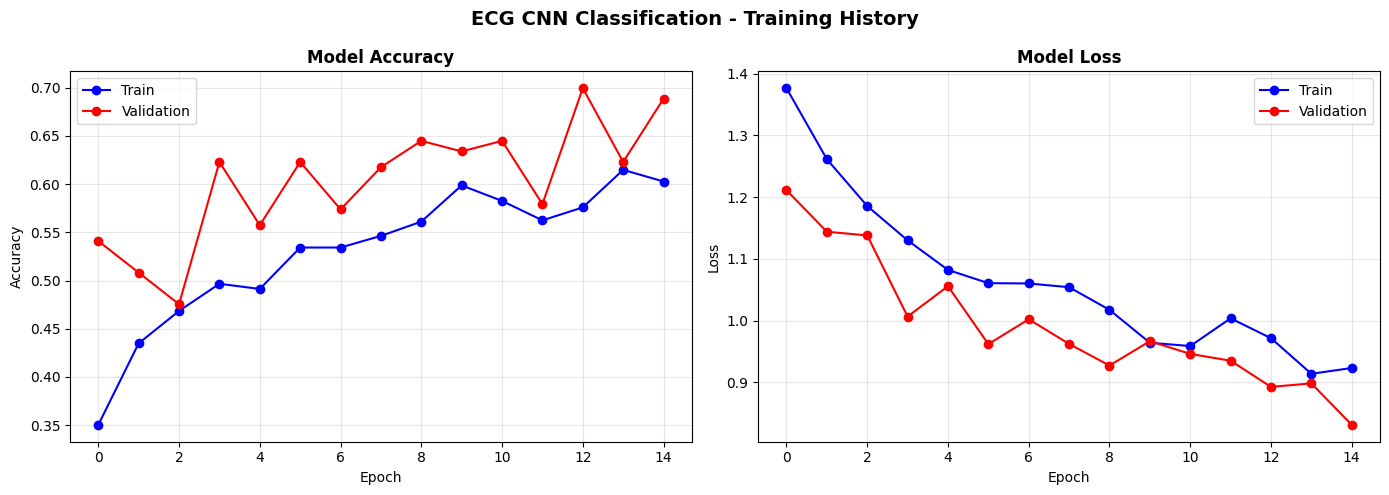

Graph saved!


In [ ]:
# Training Graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-o', label='Train')
axes[0].plot(history.history['val_accuracy'], 'r-o', label='Validation')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], 'b-o', label='Train')
axes[1].plot(history.history['val_loss'], 'r-o', label='Validation')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ECG CNN Classification - Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150)
plt.show()
print("Graph saved!")

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6420 - loss: 0.9019
Validation Accuracy: 65.57%
Validation Loss: 0.9078


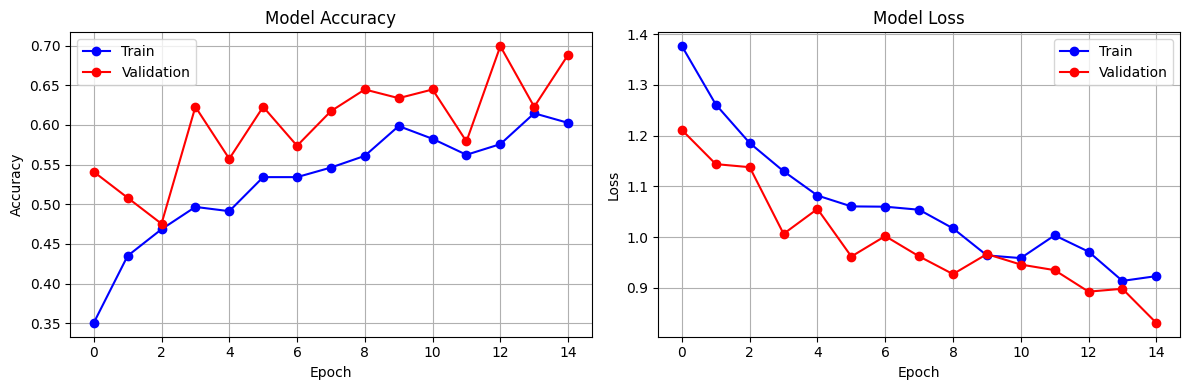

Graphs saved!


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-o', label='Train')
plt.plot(history.history['val_accuracy'], 'r-o', label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-o', label='Train')
plt.plot(history.history['val_loss'], 'r-o', label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_graphs.png')
plt.show()
print("Graphs saved!")

6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


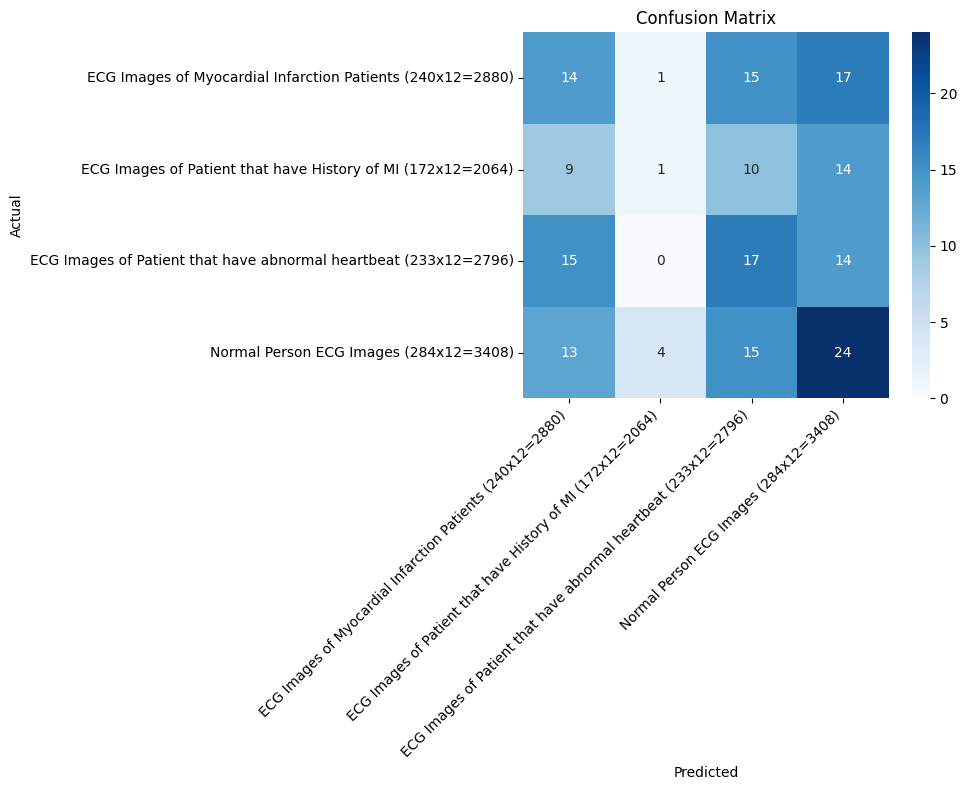

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.27      0.30      0.29        47
     ECG Images of Patient that have History of MI (172x12=2064)       0.17      0.03      0.05        34
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.30      0.37      0.33        46
                          Normal Person ECG Images (284x12=3408)       0.35      0.43      0.38        56

                                                        accuracy                           0.31       183
                                                       macro avg       0.27      0.28      0.26       183
                                                    weighted avg       0.28      0.31      0.28       183



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_generator.reset()
preds = model.predict(val_generator)
predicted_classes = np.argmax(preds, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png')
plt.show()
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [ ]:
# Fine-tuning - unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

loss, accuracy = model.evaluate(val_generator)
print(f"New Accuracy: {accuracy*100:.2f}%")

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.3814 - loss: 2.1351 - val_accuracy: 0.3825 - val_loss: 1.6710 - learning_rate: 1.0000e-04
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.5483 - loss: 1.0840 - val_accuracy: 0.4153 - val_loss: 1.4430 - learning_rate: 1.0000e-04
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5680 - loss: 1.0103 - val_accuracy: 0.5191 - val_loss: 1.2706 - learning_rate: 1.0000e-04
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6468 - loss: 0.8499 - val_accuracy: 0.3770 - val_loss: 2.1547 - learning_rate: 1.0000e-04
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6584 - loss: 0.8225 - val_accuracy: 0.3880 - val_loss: 1.9558 - learning_rate: 1.0000e-04
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6645 - loss: 0.7845 - val_accuracy: 0.3934 - val_loss: 2.1400 - learning_rate: 1.0000e-04
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7252 - loss:

In [ ]:
model.save('/content/drive/MyDrive/ecg_cnn_model.h5')
print("Model saved!")

Model saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
folders = os.listdir('/content/drive/MyDrive/ECG_Images')
print(folders)

['ECG Images of Patient that have History of MI (172x12=2064)', 'Normal Person ECG Images (284x12=3408)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'ECG Images of Myocardial Infarction Patients (240x12=2880)']


In [ ]:
import os
folder = '/content/drive/MyDrive/ECG_Images/Normal Person ECG Images (284x12=3408)'
files = os.listdir(folder)
print(files[:5])

['Normal(104).jpg', 'Normal(12).jpg', 'Normal(115).jpg', 'Normal(128).jpg', 'Normal(136).jpg']


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/ecg_cnn_model.h5')
print("Model loaded!")

Model loaded!


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


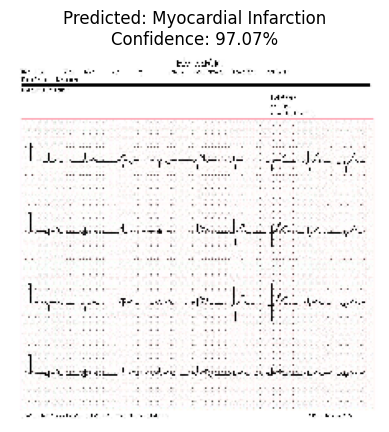

Result: Myocardial Infarction
Confidence: 97.07%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/drive/MyDrive/ECG_Images/Normal Person ECG Images (284x12=3408)/Normal(104).jpg'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)
class_names = ['Myocardial Infarction', 'History of MI', 'Abnormal Heartbeat', 'Normal']
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence:.2f}%')
plt.axis('off')
plt.show()
print(f"Result: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
import os
files = os.listdir('/content')
print(files)

['.config', 'drive', 'sample_data']
